In [1]:
import pandas as pd 
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

In [3]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
 

    # Sombreado
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

In [4]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [5]:
def print_categorias(dataframe, columna):
    print(f"Cantidad de categorías que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorías presentes en la variable '{columna}': {dataframe[columna].unique()}\n")
    
    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    
    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})
    
    print(f"Frecuencias de cada categoría en la variable '{columna}':\n{freq_tabla}\n")

In [6]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal') # Asegura que el gráfico sea circular

In [2]:
def plot_frecuencias_relativas(data, column, ax=None, palette='viridis', figsize=(9, 4), title=None):
    total = len(data)
    relative_freq = data[column].value_counts() / total

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(x=relative_freq.values, y=relative_freq.index, hue=relative_freq.index, 
                palette=palette, ax=ax, legend=False)
    
    ax.set_title(title if title else f'Frecuencias relativas de {column}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)

plt.show()

In [8]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Violin plot
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')

    # Box plot
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')

    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [4]:
pokemon_df = pd.read_csv('Pokemon.csv')

In [10]:
print(f"Dimensiones del dataset original: {pokemon_df.shape}") # (filas, columnas)
pokemon_df.head() #muestra las primeras filas del dataset

Dimensiones del dataset original: (800, 13)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [11]:
# Inspección de los tipos de datos y nulos
print("TIPOS DE VARIABLES Y DATOS NULOS")
pokemon_df.info() # Muestra información sobre los tipos de datos y la presencia de valores nulos

TIPOS DE VARIABLES Y DATOS NULOS
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 75.9 KB


In [5]:
# Resumen estadístico de las variables numéricas
print("ESTADÍSTICA DESCRIPTIVA")
pokemon_df.describe() # Muestra un resumen estadístico de las variables numéricas

ESTADÍSTICA DESCRIPTIVA


NameError: name 'pokemon_df' is not defined

In [13]:
#Estadística básica + percentiles personalizados
display(pokemon_df.describe(percentiles=[.1, .9, .95])) # Muestra un resumen estadístico de las variables numéricas con percentiles personalizados
#0.1 serviria para identificar los pokemon mas debiles mientras que 0.9 y 0.95 para los mas fuertes

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
10%,73.900000,288.00000,40.000000,40.000000,40.000000,35.000000,40.000000,30.000000,1.00000
90%,651.100000,600.00000,100.000000,125.000000,115.000000,120.000000,107.000000,106.000000,6.00000
95%,689.050000,630.00000,110.000000,136.200000,130.000000,131.050000,120.000000,115.000000,6.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [14]:
#Estadística avanzada con SciPy (Asimetría y Curtosis)
cols_numericas = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed'] #lista de columnas numéricas para el análisis
ed_pokemon = st.describe(pokemon_df[cols_numericas].dropna()) #realiza un análisis descriptivo avanzado de las columnas numéricas seleccionadas, ignorando los valores nulos

ed_pokemon_df = pd.DataFrame({ 
    'Observaciones': ed_pokemon.nobs,
    'Min': ed_pokemon.minmax[0],
    'Max': ed_pokemon.minmax[1],
    'Media': ed_pokemon.mean,
    'Varianza': ed_pokemon.variance,
    'Asimetría': ed_pokemon.skewness,
    'Curtosis': ed_pokemon.kurtosis
}, index=cols_numericas) #crea un DataFrame con los resultados del análisis descriptivo avanzado

print("\nEstadística descriptiva avanzada con SciPy:")
display(ed_pokemon_df)


Estadística descriptiva avanzada con SciPy:


,Observaciones,Min,Max,Media,Varianza,Asimetría,Curtosis
HP,800,1,255,69.25875,652.019323,1.565282,7.179466
Attack,800,5,190,79.00125,1053.480599,0.550579,0.161168
Defense,800,5,230,73.84250,972.410707,1.153744,2.701760
Sp. Atk,800,10,194,72.82000,1070.748536,0.743266,0.288544
Sp. Def,800,20,230,71.90250,774.448554,0.852416,1.610744
Speed,800,5,180,68.27750,844.511133,0.357262,-0.242452


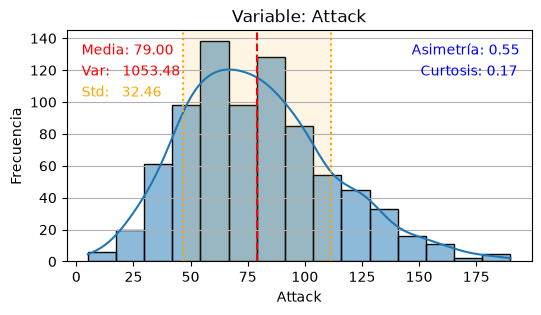

In [15]:
#Histograma para analizar como se distribuyen los puntos de ataque de los pokemones
plot_histograma(pokemon_df, 'Attack', snk=True) #snk = show normal distribution

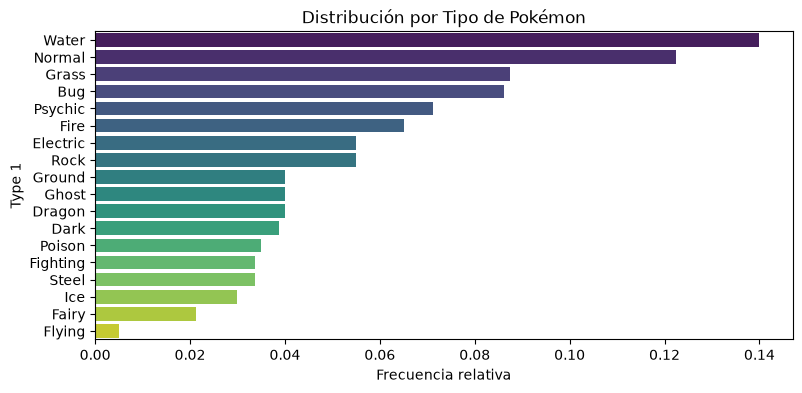

In [5]:
# Frecuencia relativa para ver cuántos tipos de pokemon hay y de que tipo hay mas o menos
plot_frecuencias_relativas(pokemon_df, 'Type 1', title='Distribución por Tipo de Pokémon')

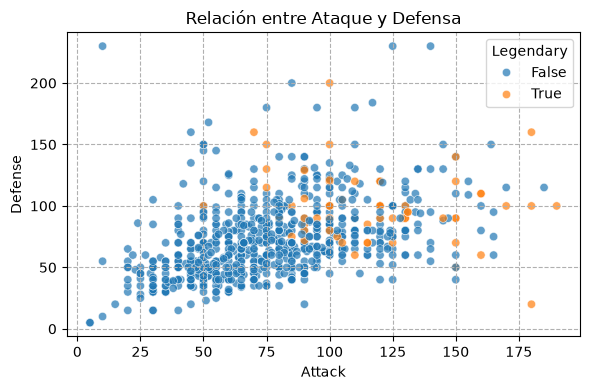

In [ ]:
# RELACIONES ENTRE VARIABLES
# Numérica-Numérica: Scatterplot
plt.figure(figsize=(6, 4)) # Configura el tamaño de la figura
sns.scatterplot(data=pokemon_df, x='Attack', y='Defense', hue='Legendary', alpha=0.7) # Crea un gráfico de dispersión
plt.grid(ls='--') # Configura la cuadrícula del gráfico
plt.title('Relación entre Ataque y Defensa')
plt.tight_layout() # Ajusta el diseño para que no se solapen los elementos
plt.show() 
#sirve para ver si un pokemon con mucho ataque suele tener tambien mucha defensa o si son estadisticas independientes

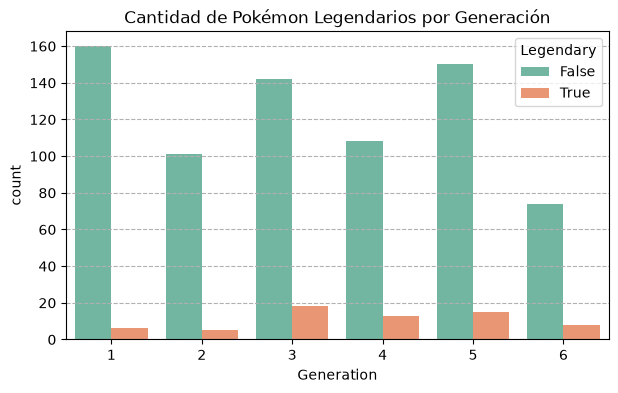

In [ ]:
#Categórica-Categórica: Grafico de barras
plt.figure(figsize=(7, 4))
sns.countplot(x='Generation', hue='Legendary', data=pokemon_df, palette='Set2') # Crea un gráfico de barras para mostrar la cantidad de pokemon legendarios por generación
plt.grid(ls='--', axis='y') # Configura la cuadrícula del gráfico solo en el eje y
plt.title("Cantidad de Pokémon Legendarios por Generación")
plt.show()
#sirve para ver como se distribuye la cantidad de Pokémon normales y legendarios a lo largo de las distintas generaciones

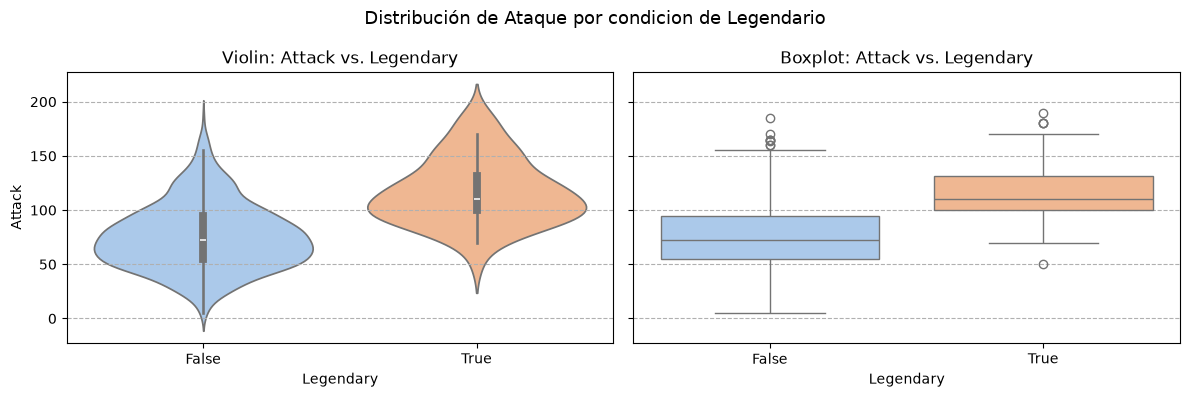

In [ ]:
#Numérica-Categórica: Violin y Boxplot
plot_violin_box(pokemon_df, num_col='Attack', cat_col='Legendary', title='Distribución de Ataque por condicion de Legendario') # sirve para ver si los Pokémon legendarios teiene mas ataque que los normales y que tan grande es esa diferencia